In [319]:

### Classical libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### Pytoch libraries
import torch
from torch_geometric.data import Data
from torch_geometric.utils import degree
import torch.nn as nn
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

### Libraries for visualizing
import folium
from IPython.display import display, HTML
import seaborn as sns

### Other libraries
import warnings
warnings.filterwarnings('ignore')

## Defining functions 

In [281]:
# Function for recovering CSV files for building SEASONS graph
# input: paths to edges and vertices files
# output: two dataframes containing vertices and edges

def read_files_season(path_edges, path_vertices, path_rating):
    vertices = pd.read_csv(path_vertices,sep=";")
    edges = pd.read_csv(path_edges,sep="\t") 
    rating = pd.read_csv(path_rating,sep=";")
    rating.rename(columns={"idplace": "id"}, inplace=True)
    vertices.rename(columns={"gid": "id"}, inplace=True)
    edges = edges.rename(columns={"gid_from":"source","gid_to":"target"})
    vertices_ratings = pd.merge(vertices, rating[['id','rating', 'NB']], on='id', how='right') 
    # if left join, some missing values appears

    columnas_A = [col for col in vertices.columns if col != 'id']
    reglas_agregacion = {col: 'first' for col in columnas_A}
    reglas_agregacion['rating'] = 'mean'
    reglas_agregacion['NB'] = lambda x: x.mode().iloc[0] if not x.mode().empty else None
    vertices_final = vertices_ratings.groupby('id').agg(reglas_agregacion).reset_index()

    return vertices_final, edges

In [282]:
# Function for re-mapping the node Ids and souce and target of edges 
# input: vertices and edges dataframes
# output: both dataframes with mapped Ids

def remap_graph_ids(vertices_df, edges_df):
    vertices = vertices_df.copy()
    edges = edges_df.copy()

    # Check that GIDs are unique
    if vertices["id"].duplicated().any():
        duplicated = vertices.loc[
            vertices["id"].duplicated(),
            "id"
        ].tolist()

        raise ValueError(
            f"Duplicated vertex GIDs found: {duplicated[:10]}"
        )

    # Create consecutive node indices

    vertices["node_idx"] = range(len(vertices))

    # original GID -> consecutive PyTorch node index
    gid_to_idx = dict(
        zip(
            vertices["id"],
            vertices["node_idx"]
        )
    )

    # 3. Map source and target GIDs
    edges["source_idx"] = edges["source"].map(gid_to_idx)
    edges["target_idx"] = edges["target"].map(gid_to_idx)

    # Check for GIDs that do not exist in vertices

    invalid_source = edges["source_idx"].isna()
    invalid_target = edges["target_idx"].isna()

    if invalid_source.any() or invalid_target.any():

        missing_source = edges.loc[
            invalid_source, "source"
        ].unique()

        missing_target = edges.loc[
            invalid_target, "target"
        ].unique()

        raise ValueError(
            "Some edge GIDs do not exist in vertices.\n"
            f"Missing source GIDs: {missing_source[:10]}\n"
            f"Missing target GIDs: {missing_target[:10]}"
        )

    # Convert indices to integers
    edges["source_idx"] = edges["source_idx"].astype(int)
    edges["target_idx"] = edges["target_idx"].astype(int)

    # Consistency checks
    n_nodes = len(vertices)

    assert vertices["node_idx"].min() == 0
    assert vertices["node_idx"].max() == n_nodes - 1

    assert edges["source_idx"].min() >= 0
    assert edges["target_idx"].min() >= 0

    assert edges["source_idx"].max() < n_nodes
    assert edges["target_idx"].max() < n_nodes

    # Replace the old Ids with the new ones

    vertices.drop('id', axis=1, inplace=True)
    edges.drop('source', axis=1, inplace=True)
    edges.drop('target', axis=1, inplace=True)
    vertices.rename({'node_idx': 'id'}, axis=1, inplace=True)
    edges.rename({'source_idx': 'source', 'target_idx': 'target'}, axis=1, inplace=True)
    #vertices.drop('id_aux', axis=1, inplace=True)
    #edges.drop('source_idx', axis=1, inplace=True)
    #edges.drop('target_idx', axis=1, inplace=True)

    return vertices, edges

In [283]:
# Function for creating a torch graph
# input: edges and vertices dataframes
# output: a torch graph

def torch_graph_building(vertices, edges):
    #features = vertices[["id", "rating", "NB","typeR"]].values
    features = np.array(vertices[["rating", "NB"]].values,  dtype=np.float16)
    #features = vertices[vertices.columns.to_list()].values
    x = torch.tensor(features, dtype=torch.float)
    # Edges
    edge_index = torch.tensor(
        edges[["source", "target"]].values.T,
        dtype=torch.long
    )
    # Create graph
    data = Data(
        x=x,
        edge_index=edge_index
    )
    return data

In [284]:
# Function for deleting the ID and adding the degree (for embedding purposes)
# input: a graph 
# output: the same graph with new attribute

def add_degree(g):
    out_degree = degree(g.edge_index[0], num_nodes=g.num_nodes)
    in_degree = degree(g.edge_index[1], num_nodes=g.num_nodes)
    total_degree = in_degree + out_degree

    # Concatenamos las columnas seleccionadas (o todo g.x) con total_degree
    X = g.x.float()
    g.x = torch.cat([X, total_degree.unsqueeze(1)], dim=1)

    return g

In [285]:
# Class for implementing a graph embedding using a GNN (only 2 layers)
# input: node characteristics
# output: the embedding of size input_dim x embedding_dim

class PoIEncoder(torch.nn.Module):

    def __init__(self, input_dim, embedding_dim):

        super().__init__()
        self.conv1 = GCNConv(input_dim, 32)
        self.conv2 = GCNConv(32, embedding_dim)

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        z = self.conv2(x, edge_index)

        return z

In [ ]:
# Function for visualizing a PoI and the recommendation
# input: two points
# output: a map

def visualizing_points(point_1, point_2, zoom):
    # Calculating the center of our map
    center_lat = (point_1[0] + point_2[0]) / 2
    center_lon = (point_1[1] + point_2[1]) / 2
    mapa = folium.Map(location=[center_lat, center_lon], zoom_start=zoom)

    # Añadir los marcadores
    folium.Marker(point_1, popup='Current PoI').add_to(mapa)
    folium.Marker(point_2, popup='Next PoI').add_to(mapa)

    return mapa

    # Save the figure
    #mapa.save("mapa_puntos.html")

## Recovering the data

In [287]:
### Data recovering and graph buiding

edges_file = "tripadvisorcorefua_Lille_circulationGraph.csv"
vertices_file = "tripadvisorcorefua_Lille_locations.csv"
#vertices_file = "MEL_tripLocation.csv"
rating_file = "tripadvisorcorefua_Lille_locations_evolution.csv"
vertices, edges = read_files_season(edges_file, vertices_file, rating_file)
#vertices.rename(columns={"gid": "id"}, inplace=True)
vertices['id_aux'] = vertices.reset_index().index # +1 for starting from 1

In [288]:
vertices.head()

,id,nom,latitude,longitude,typeR,hotelType,restaurantType,activiteType,rating,NB,id_aux
0,196912,Mercure Lille Centre Grand Place,50.63817,3.065553,H,hotel,NaN,NaN,3.917488,11,0
1,196913,Mercure Lille Roubaix Grand Hotel,50.69226,3.172287,H,hotel,NaN,NaN,3.802005,2,1
2,196916,Ibis Lille Centre Gares,50.63469,3.070875,H,hotel,NaN,NaN,3.847059,11,2
3,196917,Ibis Styles Lille Centre Gare Beffroi,50.63252,3.067851,H,hotel,NaN,NaN,3.437920,12,3
4,196918,Ibis Styles Lille Centre Grand Place,50.63760,3.066830,H,hotel,NaN,NaN,3.969334,9,4


In [289]:
edges.head()

,source,target,year,month,country,NbPerMaxDurationDays_1,NbPerMaxDurationDays_3,NbPerMaxDurationDays_5,NbPerMaxDurationDays_7,NbPerMaxDurationDays_14,NbPerMaxDurationDays_inf
0,1323722,1327641,2014,2,France,0,0,0,0,0,1
1,1323722,3365098,2017,10,France,1,1,1,1,1,1
2,1323722,2721700,2017,12,France,0,0,0,0,0,1
3,1323722,1333841,2015,9,France,0,0,0,0,0,1
4,1323722,1338254,2013,2,France,0,0,0,0,0,1


In [290]:
# Selecting the node's features I need

vertices = vertices[["id","nom","latitude","longitude","typeR","rating","NB"]]
vertices.head()
#vertices.to_csv("nodes.csv")

,id,nom,latitude,longitude,typeR,rating,NB
0,196912,Mercure Lille Centre Grand Place,50.63817,3.065553,H,3.917488,11
1,196913,Mercure Lille Roubaix Grand Hotel,50.69226,3.172287,H,3.802005,2
2,196916,Ibis Lille Centre Gares,50.63469,3.070875,H,3.847059,11
3,196917,Ibis Styles Lille Centre Gare Beffroi,50.63252,3.067851,H,3.437920,12
4,196918,Ibis Styles Lille Centre Grand Place,50.63760,3.066830,H,3.969334,9


In [291]:
vertices.isna().sum()

id           0
nom          0
latitude     0
longitude    0
typeR        0
rating       0
NB           0
dtype: int64

In [292]:
vertices.shape

(2236, 7)

In [293]:
# Selecting the edge's features I need 

edges = edges[["source","target","year","month","country"]]
edges.head()
#edges.to_csv("edges.csv")

,source,target,year,month,country
0,1323722,1327641,2014,2,France
1,1323722,3365098,2017,10,France
2,1323722,2721700,2017,12,France
3,1323722,1333841,2015,9,France
4,1323722,1338254,2013,2,France


In [294]:
# In some cases, some nodes do not appear in edges (or viciversa)
# Uncoment if vertices ID doesn't exist in edges dataset

new_vertices, new_edges = remap_graph_ids(vertices, edges)

In [295]:
print(new_edges.shape)
print(new_vertices.shape)

(76998, 5)
(2236, 7)


## Analyzing edges

In [311]:
new_edges.shape

(76998, 5)

In [339]:
new_edges.head()

,year,month,country,source,target,path,Periodo
11189,2013,1,France,84,354,11189 84\n12838 350\n68746 98\n6...,2013-01
74330,2013,1,France,355,880,11189 84\n12838 350\n68746 98\n6...,2013-01
54377,2013,1,France,439,465,11189 84\n12838 350\n68746 98\n6...,2013-01
73771,2013,1,France,314,1874,11189 84\n12838 350\n68746 98\n6...,2013-01
38566,2013,1,France,85,333,11189 84\n12838 350\n68746 98\n6...,2013-01


In [333]:
# Calculating the edge frequeny by year-mont

new_edges["path"] = new_edges["source"].to_string() + " - " + new_edges["target"].to_string() # new column

# Creting a period Year-month
new_edges["Periodo"] = (
    new_edges["year"].astype(str) + "-" + new_edges["month"].astype(str).str.zfill(2)
)

# Sorting by period
new_edges = new_edges.sort_values("Periodo")

# Obtaining the unique values
rutas_unicas = new_edges["path"].unique()

In [335]:
print(new_edges["path"].head())

11189    11189      84\n12838     350\n68746      98\n6...
74330    11189      84\n12838     350\n68746      98\n6...
54377    11189      84\n12838     350\n68746      98\n6...
73771    11189      84\n12838     350\n68746      98\n6...
38566    11189      84\n12838     350\n68746      98\n6...
Name: path, dtype: str


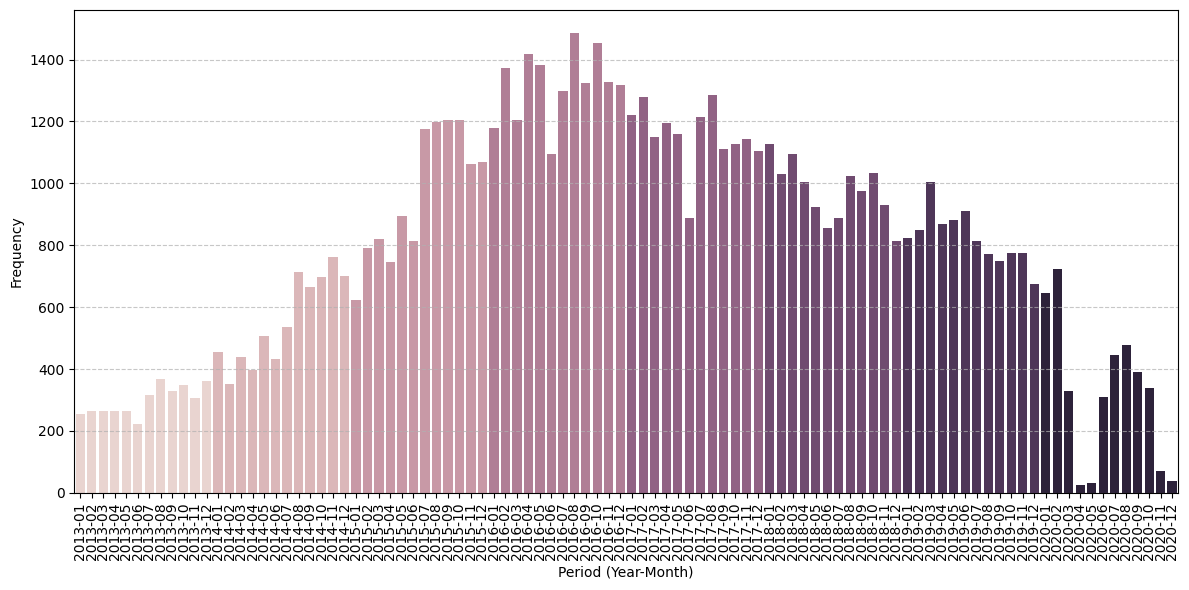

In [330]:
# Visualizing the hystogram

for ruta in rutas_unicas:
    # Filtering the dataset
    df_filtrado = new_edges[new_edges["path"] == ruta]

    plt.figure(figsize=(12, 6))

    # seaborn.countplot count the number of instances for each period
    sns.countplot(
        data=df_filtrado, x="Periodo", hue="year", dodge=False
    )

    # Plot configuration
    plt.xlabel("Period (Year-Month)", fontsize=10)
    plt.ylabel("Frequency", fontsize=10)
    plt.xticks(rotation=90)  # Rotar fechas para que no se superpongan
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend().set_visible(False)

    plt.tight_layout()

In [350]:
source_seek = 355
year_seek = 2014

# Edges filtering by year and a specific source
unique_target = new_edges[(new_edges['source'] == source_seek) 
                          & (new_edges["year"] == year_seek)][['target', 'year', 'month']].drop_duplicates()

# Ordering by target
unique_target = unique_target.sort_values(by=['target', 'year', 'month']).reset_index(drop=True)

print(unique_target.head(50))

    target  year  month
0      355  2014     11
1      356  2014      1
2      368  2014      7
3      393  2014     11
4      398  2014     11
5      406  2014      8
6      420  2014      7
7      421  2014      5
8      433  2014     11
9      434  2014     10
10     441  2014     11
11     442  2014      4
12     450  2014      7
13     507  2014     12
14     538  2014      4
15     587  2014      7
16     601  2014      2
17     601  2014      7
18     601  2014      8
19     601  2014     10
20     603  2014      3
21     603  2014      4
22     603  2014      8
23     606  2014      5
24     675  2014      6
25     713  2014      1
26     713  2014      5
27     713  2014      7
28     713  2014      9
29     713  2014     10
30     799  2014     12
31     829  2014      4
32    1060  2014      6
33    1560  2014     11
34    1700  2014      2
35    1700  2014      5
36    1700  2014     11


### Basic idea

The five instances of 355 → 713 provide repeated evidence that there is a flow between 355 and 713 (transition model)

You can think of each record as a tourist visit, even if you don't know which specific tourist took the trip.

$$P(v_{t+1} = j | v_t = i,context)$$

Where the 

$$context = (year, month, nationality,...)$$

The question we want to answer is: Given the flows observed through 2018 and knowing that a flow departs from 355 in July, which POI will be its destination in 2019?

**Problem**: Given that a tourist flow originates at POI \(i\), predict the most likely destination POI \(j\).

### Training and validation

How about the training/test? We can split the datao into two subsets:

Train: [2013-2018]

Test: [2019-2021] 

### Baseline

1. Flow baseline 

$$\hat j = \arg\max_j w_{ij} $$

2. Markov

3. Embedding baseline: The next POI is the one most similar to the current POI in the embedding space

$$\hat j = \arg\max_j sim(z_i,z_j)$$


## Building the graph using Pytorch (tensors)

In [296]:
# Creating the graph in pytorch (tensors)

g = torch_graph_building(new_vertices, new_edges)

In [297]:
# Print the graph characteristics: x -> vertices, edge_index -> edges

g

Data(x=[2236, 2], edge_index=[2, 76998])

In [298]:
# Here, we are interesting in add a new node's feature: the degree
# He have implemented a function to do that

g = add_degree(g)
g

Data(x=[2236, 3], edge_index=[2, 76998])

## Applying a 2-layer GNN

In [299]:
# Here we create the embedding. A class was implemented to this purpose
# The constructor needs 2 param: input_dim and the size of embeddings

encoder = PoIEncoder(input_dim=3, embedding_dim=16)

Z = encoder(g.x, g.edge_index)

In [300]:
print(Z.shape) # Each vertice is represented by 15 values

torch.Size([2236, 16])


## First approach: 
#### The next PoI to visit is the one that is most similar to where I am now

In [301]:
# We are located in "Westfield Euralille" (row number 9 in the dataset)
# In this approache, we are using only a PoI but not a sequence

current_poi = 9
current_embedding = Z[current_poi] # we recover their vector

print(current_embedding)

tensor([ 122.4297,  318.9883,  401.7361,  -58.4630, -111.3834,  322.4532,
        -207.1988,  207.1913,  -31.7280,   99.9651,  218.7762,  143.6689,
         245.1351,  205.2675,   25.8175, -446.3827], grad_fn=<SelectBackward0>)


In [302]:
# We calculate the most similar nodes using their embeddings

scores = Z @ current_embedding
scores[current_poi] = -float("inf") # Dropping the score for the same node
print(scores)

tensor([ 324645.4375, 1117467.0000,  992229.8750,  ...,    2889.9370,
           3225.8965,    9185.9990], grad_fn=<CopySlices>)


In [303]:
# We select the most similar to our node 9
# To do so, the argmax funcion is used

predicted_poi = torch.argmax(scores)

print(predicted_poi)
print(predicted_poi.item())

tensor(42)
42


In [304]:
# We can visualize points 9 and 42 using folium

point_1 = new_vertices.loc[current_poi][["latitude","longitude"]].to_list()
point_2 = new_vertices.loc[predicted_poi.item()][["latitude","longitude"]].to_list()
visualizing_points(point_1=point_1, point_2=point_2, zoom=13)

## Second approach:

#### The next PoI to visit is the one that is most similar to where I am now: Using the consine similarity

In [308]:
# Similar to previous approache, we calcualathe de similarity scores to the current PoI 
# But we change the way we calculate the cosine similarity. Then, we normalize the tensor using L2 Norm (p=2)

embeddings = F.normalize(Z, p=2, dim=1)

print(embeddings)

tensor([[ 0.1315,  0.3429,  0.4319,  ...,  0.2203,  0.0277, -0.4798],
        [ 0.1315,  0.3429,  0.4319,  ...,  0.2203,  0.0277, -0.4798],
        [ 0.1316,  0.3429,  0.4319,  ...,  0.2204,  0.0277, -0.4798],
        ...,
        [ 0.1670, -0.0686,  0.3364,  ...,  0.5161, -0.0273, -0.3181],
        [ 0.2223,  0.0907,  0.3926,  ...,  0.4791, -0.0034, -0.4263],
        [ 0.1754,  0.3236,  0.4168,  ...,  0.2860,  0.0464, -0.4829]],
       grad_fn=<DivBackward0>)


In [309]:
scores_cos = embeddings @ embeddings[current_poi]
scores_cos[current_poi] = -float("inf") # Dropping the score for the same node
print(scores_cos)

tensor([1.0000, 1.0000, 1.0000,  ..., 0.6052, 0.7976, 0.9908],
       grad_fn=<CopySlices>)


In [310]:
predicted_poi_cos = torch.argmax(scores_cos).item()
print(predicted_poi_cos)

4


In [353]:
# https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=10742362
# https://link.springer.com/content/pdf/10.1007/s40860-024-00233-z.pdf
# https://link.springer.com/article/10.1007/s40558-024-00301-3?utm_source=chatgpt.com
# https://arxiv.org/pdf/2410.02191?